# Pol II buffering range

## Overview

This notebook estimates the **pSer2 buffering range**: the interval of total Pol II values over which elongating (pSer2) Pol II varies by less than ±5% relative to the T=1 baseline.

Two curves are fitted to the (total Pol II, pSer2) scatter and compared:

1. **Smoothing spline** — `scipy.interpolate.UnivariateSpline` with smoothing factor $s$ selected by leave-one-out cross-validation. Model-free and makes no assumptions about functional form.
2. **MM model curve** — the steady-state elongating fraction predicted by the best-fit Michaelis-Menten ODE model from `pol_pools_mm.ipynb`, included as a mechanistic reference.

For each curve the buffering range is defined as:

$$
\mathcal{B} = \{ T : |E(T) - 1| \leq 0.05 \}
$$

where $E(T)$ is the fold-change in pSer2 at total Pol II level $T$, normalised so that $E(1) = 1$.

The lower bound $T_\mathrm{low}$ is the largest $T < 1$ at which $E(T) = 0.95$, and the upper bound $T_\mathrm{high}$ is the smallest $T > 1$ at which $E(T) = 1.05$. Crossings are located by Brent's method.

## Prerequisites

Run the export cell in `pol_pools_mm.ipynb` first to produce:
- `buffering_scatter.csv` — columns `T_fc`, `E_fc`
- `buffering_params.csv` — columns `param`, `value`

## Imports

In [87]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline
from scipy.optimize import brentq, root

## Load data

In [88]:
scatter = pd.read_csv("buffering_scatter.csv")
params = pd.read_csv("buffering_params.csv")

optimal_params = params["value"].values  # [k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np]

# Average within each dataset across experiments at each (time, conc) condition
# so that each dataset contributes equally regardless of replicate number
averaged = (
    scatter.groupby(["dataset", "time_h", "conc_nM"], dropna=False)[["T_fc", "E_fc"]]
    .mean()
    .reset_index()
)

T_data = averaged["T_fc"].values
E_data = averaged["E_fc"].values

# Sort by T — required for UnivariateSpline
order = np.argsort(T_data)
T_sorted = T_data[order]
E_sorted = E_data[order]

print(f"Loaded {len(scatter)} raw rows, averaged to {len(averaged)} points")
print(f"Points per dataset:\n{averaged.groupby('dataset').size().to_string()}")
print(f"T range: [{T_sorted.min():.3f}, {T_sorted.max():.3f}]")
print(f"Parameters: {dict(zip(params['param'], params['value'].round(4)))}")

Loaded 71 raw rows, averaged to 27 points
Points per dataset:
dataset
ARMC5                   5
mACPOLR2A_biallelic    17
mACmChPOLR2A            5
T range: [0.314, 1.686]
Parameters: {'k_pn': 4.9604, 'Vmax_pe': 0.3602, 'Km_pe': 0.0256, 'Vmax_np': 2.797, 'Km_np': 0.286}


In [89]:
scatter

,T_fc,E_fc,dataset,experiment,time_h,conc_nM
0,1.020464,1.000000,mACPOLR2A_biallelic,250905,0.0,0.0
1,0.764212,0.971021,mACPOLR2A_biallelic,250905,1.0,10.0
2,0.578879,0.887309,mACPOLR2A_biallelic,250905,1.0,100.0
3,0.531341,0.868078,mACPOLR2A_biallelic,250905,1.0,1000.0
4,0.508149,0.864989,mACPOLR2A_biallelic,250905,1.0,10000.0
...,...,...,...,...,...,...
66,1.000000,1.000000,ARMC5,averaged,0.0,NaN
67,1.151005,1.013681,ARMC5,averaged,2.0,NaN
68,1.418373,1.020836,ARMC5,averaged,8.0,NaN
69,1.611447,1.051199,ARMC5,averaged,24.0,NaN


## Settings

In [90]:
THRESHOLD = 0.05  # ±5% pSer2 tolerance
T_BASELINE = 1.0  # normalisation point
LOWER_TARGET = 1.0 - THRESHOLD  # 0.95
UPPER_TARGET = 1.0 + THRESHOLD  # 1.05

# Fine grid for curve evaluation and root-finding
T_grid = np.linspace(T_sorted.min(), T_sorted.max(), 2000)

## MM model curve

Re-evaluate the steady-state elongating fraction $E(T) / E(1)$ using the best-fit parameters from `pol_pools_mm.ipynb`. The steady state satisfies:

1. $N + P + E - T = 0$
2. $\frac{V_{max,PE}\,P}{K_{m,PE} + P} - k_{EN}\,E = 0$
3. $\frac{V_{max,NP}\,N}{K_{m,NP} + N} - k_{PN}\,P - \frac{V_{max,PE}\,P}{K_{m,PE} + P} = 0$

In [91]:
def get_steady_state(T, params):
    """Return steady-state (N, P, E) for total Pol II = T."""
    k_pn, Vmax_pe, Km_pe, Vmax_np, Km_np = params
    k_en = 1.0

    def equations(x):
        N, P, E = x
        eq1 = N + P + E - T
        eq2 = (Vmax_pe * P) / (Km_pe + P) - k_en * E
        eq3 = (Vmax_np * N) / (Km_np + N) - k_pn * P - (Vmax_pe * P) / (Km_pe + P)
        return [eq1, eq2, eq3]

    x0 = [T / 3, T / 3, T / 3]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sol = root(equations, x0, method="hybr", tol=1e-10)

    if sol.success and all(v >= -1e-9 for v in sol.x):
        return {"converged": True, "solution": np.maximum(sol.x, 0)}
    return {"converged": False, "solution": [np.nan, np.nan, np.nan]}


# Normalise to E at T=1
baseline = get_steady_state(T_BASELINE, optimal_params)
E_base = baseline["solution"][2]

mm_E = []
for T_val in T_grid:
    res = get_steady_state(T_val, optimal_params)
    mm_E.append(res["solution"][2] / E_base if res["converged"] else np.nan)
mm_E = np.array(mm_E)

print(f"MM model evaluated at {np.sum(~np.isnan(mm_E))}/{len(T_grid)} grid points")

MM model evaluated at 2000/2000 grid points


## Smoothing spline

Fit a cubic smoothing spline (`UnivariateSpline`, $k=3$) directly to the raw scatter. The smoothing factor $s$ controls the trade-off between closeness of fit and smoothness: larger $s$ gives a smoother curve that may not pass through all data points. $s$ is selected by leave-one-out cross-validation.

In [92]:
def cv_spline_score(log_s, T_s, E_s):
    """Leave-one-out MSE for UnivariateSpline with smoothing s = exp(log_s)."""
    s = np.exp(log_s)
    n = len(T_s)
    errors = []
    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False
        try:
            sp = UnivariateSpline(T_s[mask], E_s[mask], k=3, s=s, ext=3)
            errors.append((sp(T_s[i]) - E_s[i]) ** 2)
        except Exception:
            errors.append(np.nan)
    return np.nanmean(errors)


# Search over a log-spaced grid of smoothing values
log_s_grid = np.linspace(-4, 4, 40)
cv_scores = [cv_spline_score(ls, T_sorted, E_sorted) for ls in log_s_grid]
best_log_s = log_s_grid[np.nanargmin(cv_scores)]
best_s = np.exp(best_log_s)

spline = UnivariateSpline(T_sorted, E_sorted, k=3, s=best_s, ext=3)
spline_E = spline(T_grid)

print(f"CV-selected smoothing factor s = {best_s:.4g}")
print(f"LOO-CV MSE at best s = {np.nanmin(cv_scores):.6f}")

CV-selected smoothing factor s = 0.01832
LOO-CV MSE at best s = 0.000648


## Find buffering range

For each curve, locate the ±5% crossings by Brent's method and define the buffering range as $[T_\mathrm{low},\, T_\mathrm{high}]$. If no crossing exists at the lower end of the data range (i.e. pSer2 never drops to 0.95 across the observed T values), $T_\mathrm{low}$ defaults to the minimum observed T.

In [93]:
def find_crossings(T_grid, E_curve, target, baseline_T=T_BASELINE):
    """
    Return (T_lower, T_upper) where E_curve crosses `target`,
    searching to the left and right of baseline_T respectively.
    Returns np.nan if no crossing is found in that half.
    """
    idx_base = np.searchsorted(T_grid, baseline_T)

    def f(t):
        return np.interp(t, T_grid, E_curve) - target

    # Lower crossing: largest T < baseline where curve == target
    T_lower = np.nan
    left_segment = T_grid[:idx_base]
    left_vals = E_curve[:idx_base] - target
    sign_changes = np.where(np.diff(np.sign(left_vals)))[0]
    if len(sign_changes) > 0:
        idx = sign_changes[-1]  # closest to baseline
        try:
            T_lower = brentq(f, left_segment[idx], left_segment[idx + 1])
        except ValueError:
            pass

    # Upper crossing: smallest T > baseline where curve == target
    T_upper = np.nan
    right_segment = T_grid[idx_base:]
    right_vals = E_curve[idx_base:] - target
    sign_changes = np.where(np.diff(np.sign(right_vals)))[0]
    if len(sign_changes) > 0:
        idx = sign_changes[0]  # closest to baseline
        try:
            T_upper = brentq(f, right_segment[idx], right_segment[idx + 1])
        except ValueError:
            pass

    return T_lower, T_upper


def buffering_range(T_grid, E_curve, threshold=THRESHOLD, baseline_T=T_BASELINE):
    """
    Return (T_low, T_high) defining the buffering range:
      T_low  = T where E drops to (1 - threshold) to the left of baseline
      T_high = T where E rises to (1 + threshold) to the right of baseline
    Defaults to grid edge if no crossing found.
    """
    T_low, _ = find_crossings(T_grid, E_curve, LOWER_TARGET, baseline_T)
    _, T_high = find_crossings(T_grid, E_curve, UPPER_TARGET, baseline_T)

    T_low = T_low if not np.isnan(T_low) else T_grid.min()
    T_high = T_high if not np.isnan(T_high) else T_grid.max()
    return T_low, T_high


spline_range = buffering_range(T_grid, spline_E)
mm_range = buffering_range(T_grid, mm_E)

print(f"Smoothing spline : [{spline_range[0]:.3f},  {spline_range[1]:.3f}]")
print(f"MM model         : [{mm_range[0]:.3f},  {mm_range[1]:.3f}]")

Smoothing spline : [0.675,  1.608]
MM model         : [0.673,  1.686]


## Plot

In [94]:
averaged

,dataset,time_h,conc_nM,T_fc,E_fc
0,ARMC5,0.0,NaN,1.000000,1.000000
1,ARMC5,2.0,NaN,1.151005,1.013681
2,ARMC5,8.0,NaN,1.418373,1.020836
3,ARMC5,24.0,NaN,1.611447,1.051199
4,ARMC5,48.0,NaN,1.686175,1.075193
5,mACPOLR2A_biallelic,0.0,0.0,1.000000,1.000000
6,mACPOLR2A_biallelic,1.0,10.0,0.722250,0.997966
7,mACPOLR2A_biallelic,1.0,100.0,0.551551,0.920671
8,mACPOLR2A_biallelic,1.0,1000.0,0.504242,0.887055
9,mACPOLR2A_biallelic,1.0,10000.0,0.484640,0.871306


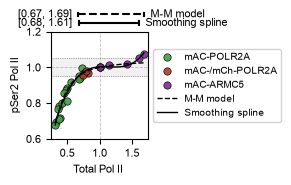

In [95]:
# Convert cm to inches (1 inch = 2.54 cm)
fig, ax = plt.subplots(figsize=(7.5 / 2.54, 5 / 2.54))

# Set Arial font throughout
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

# Dataset color mapping
dataset_colors = {
    "mACPOLR2A_biallelic": "#419c46",
    "mACmChPOLR2A": "#a73f23",
    "ARMC5": "#7c2c91",
}

# Dataset label mapping for legend
dataset_labels = {
    "mACPOLR2A_biallelic": "mAC-POLR2A",
    "mACmChPOLR2A": "mAC-/mCh-POLR2A",
    "ARMC5": "mAC-ARMC5",
}

# Shade the ±5% region behind everything
ax.axhspan(LOWER_TARGET, UPPER_TARGET, color="lightgray", alpha=0.3, zorder=0)

# Plot data by dataset
for dataset_name, color in dataset_colors.items():
    mask = (averaged["dataset"] == dataset_name).values  # Convert to numpy array
    if mask.any():
        ax.scatter(
            T_data[mask],
            E_data[mask],
            color=color,
            s=28,
            alpha=0.9,
            edgecolors="black",
            linewidths=0.5,
            zorder=3,
            label=dataset_labels[dataset_name],
        )

# Fitted curves
ax.plot(T_grid, mm_E, color="black", lw=1.0, ls="--", label="M-M model", zorder=4)
ax.plot(
    T_grid, spline_E, color="black", lw=1.0, ls="-", label="Smoothing spline", zorder=5
)

# ±5% reference lines
ax.axhline(LOWER_TARGET, color="gray", lw=0.6, ls=":", zorder=1)
ax.axhline(UPPER_TARGET, color="gray", lw=0.6, ls=":", zorder=1)
ax.axhline(1.0, color="gray", lw=0.6, ls="--", alpha=0.5, zorder=1)
ax.axvline(T_BASELINE, color="gray", lw=0.6, ls="--", alpha=0.5, zorder=1)

# Set y-limits
ylim = (0.6, 1.2)
y_range = ylim[1] - ylim[0]

# Buffering range bars outside plot region with increased spacing
bar_y_base = ylim[1] + 0.08 * y_range  # Increased spacing from plot
bar_y_mm = ylim[1] + 0.16 * y_range  # Increased spacing between bars
cap_height = 0.015 * y_range  # Height of the vertical caps

# Spline bar - solid line to match spline curve
line_spline = ax.plot(
    [spline_range[0], spline_range[1]],
    [bar_y_base, bar_y_base],
    color="black",
    lw=1.5,
    ls="-",
    solid_capstyle="butt",
    clip_on=False,
    zorder=10,
)
# Vertical caps for spline bar
ax.plot(
    [spline_range[0], spline_range[0]],
    [bar_y_base - cap_height, bar_y_base + cap_height],
    color="black",
    lw=1.5,
    ls="-",
    clip_on=False,
    zorder=10,
)
ax.plot(
    [spline_range[1], spline_range[1]],
    [bar_y_base - cap_height, bar_y_base + cap_height],
    color="black",
    lw=1.5,
    ls="-",
    clip_on=False,
    zorder=10,
)
# Numerical range on the left
text_spline_range = ax.text(
    spline_range[0] - 0.10,
    bar_y_base,
    f"[{spline_range[0]:.2f}, {spline_range[1]:.2f}]",
    ha="right",
    va="center",
    fontsize=8,
    color="black",
    clip_on=False,
)
# Model label on the right
text_spline_label = ax.text(
    spline_range[1] + 0.10,
    bar_y_base,
    "Smoothing spline",
    ha="left",
    va="center",
    fontsize=8,
    color="black",
    clip_on=False,
)

# M-M model bar - dashed line to match M-M curve
line_mm = ax.plot(
    [mm_range[0], mm_range[1]],
    [bar_y_mm, bar_y_mm],
    color="black",
    lw=1.5,
    ls="--",
    solid_capstyle="butt",
    clip_on=False,
    zorder=10,
)
# Vertical caps for M-M bar
ax.plot(
    [mm_range[0], mm_range[0]],
    [bar_y_mm - cap_height, bar_y_mm + cap_height],
    color="black",
    lw=1.5,
    ls="-",
    clip_on=False,
    zorder=10,
)
ax.plot(
    [mm_range[1], mm_range[1]],
    [bar_y_mm - cap_height, bar_y_mm + cap_height],
    color="black",
    lw=1.5,
    ls="-",
    clip_on=False,
    zorder=10,
)
# Numerical range on the left
text_mm_range = ax.text(
    mm_range[0] - 0.10,
    bar_y_mm,
    f"[{mm_range[0]:.2f}, {mm_range[1]:.2f}]",
    ha="right",
    va="center",
    fontsize=8,
    color="black",
    clip_on=False,
)
# Model label on the right
text_mm_label = ax.text(
    mm_range[1] + 0.10,
    bar_y_mm,
    "M-M model",
    ha="left",
    va="center",
    fontsize=8,
    color="black",
    clip_on=False,
)

# Set y-limits (bars will be outside the plot region)
ax.set_ylim(ylim)

# Set aspect ratio to 1
# ax.set_aspect('equal', adjustable='box')

ax.set_xlabel("Total Pol II ", fontsize=8)
ax.set_ylabel("pSer2 Pol II", fontsize=8)
ax.legend(fontsize=7, loc="center left", bbox_to_anchor=(1, 0.5), framealpha=0.9)
ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("buffering_range.pdf", dpi=300, format="pdf")
plt.show()

## Save results

In [96]:
results = pd.DataFrame(
    {
        "method": ["smoothing_spline", "mm_model"],
        "T_low": [spline_range[0], mm_range[0]],
        "T_high": [spline_range[1], mm_range[1]],
        "width": [
            spline_range[1] - spline_range[0],
            mm_range[1] - mm_range[0],
        ],
        "cv_param": [f"s={best_s:.4g}", "n/a"],
    }
)

results

,method,T_low,T_high,width,cv_param
0,smoothing_spline,0.675040,1.608315,0.933275,s=0.01832
1,mm_model,0.673111,1.686175,1.013064,n/a


In [97]:
# Find all doses where Total Pol II falls below the buffering range
# Using the more conservative M-M model lower bound
T_low_threshold = mm_range[0]

below_range = averaged[averaged["T_fc"] < T_low_threshold].copy()
below_range = below_range.sort_values(["dataset", "time_h", "conc_nM"])

print(f"Doses with Total Pol II < {T_low_threshold:.3f} (M-M model lower bound):")
print(f"\nFound {len(below_range)} conditions below the buffering range:\n")
print(below_range.to_string(index=False))

# Summary by dataset
print("\n" + "=" * 60)
print("Summary by dataset:")
print("=" * 60)
for dataset in below_range["dataset"].unique():
    dataset_subset = below_range[below_range["dataset"] == dataset]
    print(f"\n{dataset}:")
    if "conc_nM" in dataset_subset.columns and dataset_subset["conc_nM"].notna().any():
        print(f"  {len(dataset_subset)} timepoints × dose combinations")
        doses = dataset_subset["conc_nM"].dropna().unique()
        print(f"  Doses: {sorted(doses)} nM")
    else:
        print(f"  {len(dataset_subset)} timepoints")

Doses with Total Pol II < 0.673 (M-M model lower bound):

Found 12 conditions below the buffering range:

            dataset  time_h  conc_nM     T_fc     E_fc
mACPOLR2A_biallelic     1.0    100.0 0.551551 0.920671
mACPOLR2A_biallelic     1.0   1000.0 0.504242 0.887055
mACPOLR2A_biallelic     1.0  10000.0 0.484640 0.871306
mACPOLR2A_biallelic     2.0    100.0 0.444944 0.855695
mACPOLR2A_biallelic     2.0   1000.0 0.371455 0.781776
mACPOLR2A_biallelic     2.0  10000.0 0.351996 0.764361
mACPOLR2A_biallelic     4.0    100.0 0.417751 0.801168
mACPOLR2A_biallelic     4.0   1000.0 0.333713 0.696767
mACPOLR2A_biallelic     4.0  10000.0 0.313704 0.680074
mACPOLR2A_biallelic     8.0    100.0 0.490385 0.810299
mACPOLR2A_biallelic     8.0   1000.0 0.381624 0.718966
mACPOLR2A_biallelic     8.0  10000.0 0.369316 0.713852

Summary by dataset:

mACPOLR2A_biallelic:
  12 timepoints × dose combinations
  Doses: [np.float64(100.0), np.float64(1000.0), np.float64(10000.0)] nM
